In [1]:
# ── Same libraries as original, just PyTorch instead of TensorFlow ──
!pip install timm --quiet

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

In [2]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# Load Dataset from Google Drive


In [3]:
from google.colab import drive
import shutil, os

drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/PBC_dataset_normal_DIB'
LOCAL     = '/content/PBC_dataset_normal_DIB'

if not os.path.exists(LOCAL):
    print('Copying from Drive to local SSD...')
    shutil.copytree(DRIVE_DIR, LOCAL)
    print('Done')
else:
    print('Dataset already exists — skipping copy')

# Check structure
print('\nFolder structure:')
for root, dirs, files in os.walk(LOCAL):
    depth = root.replace(LOCAL, '').count(os.sep)
    if depth <= 2:
        print('  '*depth + os.path.basename(root) + f'/  ({len(files)} files)')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying from Drive to local SSD...
Done

Folder structure:
PBC_dataset_normal_DIB/  (0 files)
  ig/  (2895 files)
  eosinophil/  (3117 files)
  neutrophil/  (3330 files)
  basophil/  (1218 files)
  erythroblast/  (1551 files)
  monocyte/  (1420 files)
  platelet/  (2348 files)
  lymphocyte/  (1214 files)


# Set Paths

In [4]:
DATADIR = '/content/PBC_dataset_normal_DIB'

CATEGORIES = sorted([
    d for d in os.listdir(DATADIR)
    if os.path.isdir(os.path.join(DATADIR, d))
])
NUM_CLASSES = len(CATEGORIES)
IMG_SIZE    = 224

print(f'Classes ({NUM_CLASSES}): {CATEGORIES}')
print('\nImages per class:')
for cat in CATEGORIES:
    n = len(os.listdir(os.path.join(DATADIR, cat)))
    print(f'  {cat:30s}: {n}')

Classes (8): ['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']

Images per class:
  basophil                      : 1218
  eosinophil                    : 3117
  erythroblast                  : 1551
  ig                            : 2895
  lymphocyte                    : 1214
  monocyte                      : 1420
  neutrophil                    : 3330
  platelet                      : 2348


# Load Image into X and y

In [5]:
X, y = [], []

for category in CATEGORIES:
    path  = os.path.join(DATADIR, category)
    label = CATEGORIES.index(category)
    imgs  = [f for f in os.listdir(path)
              if f.lower().endswith(('.jpg','.jpeg','.png'))]
    for img_name in imgs:
        try:
            img = cv2.imread(os.path.join(path, img_name))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img)
            y.append(label)
        except:
            pass

X = np.array(X)
y = np.array(y)
print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')

X shape : (17092, 224, 224, 3)
y shape : (17092,)


# Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train : {X_train.shape[0]} images')
print(f'Test  : {X_test.shape[0]} images')

Train : 13673 images
Test  : 3419 images


# Dataset and Dataloader

In [7]:
train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.3),
    transforms.RandomAffine(degrees=25, scale=(0.8, 1.2)),
    transforms.ColorJitter(brightness=0.2, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                          [0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                          [0.229, 0.224, 0.225]),
])

class BloodCellDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X, self.y, self.transform = X, y, transform
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        img = self.transform(self.X[idx]) if self.transform else self.X[idx]
        return img, torch.tensor(self.y[idx], dtype=torch.long)

train_loader = DataLoader(
    BloodCellDataset(X_train, y_train, train_transforms),
    batch_size=32, shuffle=True, num_workers=2, pin_memory=True)

test_loader = DataLoader(
    BloodCellDataset(X_test, y_test, val_transforms),
    batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 428
Test batches  : 107


# Build Model

In [8]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

backbone = timm.create_model('efficientnet_b0', pretrained=True)

# Freeze backbone
for param in backbone.parameters():
    param.requires_grad = False

# Replace classifier head
in_features = backbone.classifier.in_features
backbone.classifier = nn.Sequential(
    nn.Linear(in_features, 1024),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES),
)

model = backbone.to(DEVICE)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params : {trainable:,}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Trainable params : 1,840,648


# Train

In [9]:
import time

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5)

EPOCHS    = 40
PATIENCE  = 5
SAVE_PATH = 'efficientnet_wbc_best.pt'

history          = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
best_acc         = 0.0
patience_counter = 0

print(f'{"Epoch":>6} {"Train Loss":>11} {"Train Acc":>10} {"Val Loss":>9} {"Val Acc":>8}')
print('-'*55)

for epoch in range(1, EPOCHS+1):
    start = time.time()

    # Train
    model.train()
    tl, tc, tt = 0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        tl += loss.item() * imgs.size(0)
        tc += (out.argmax(1) == lbls).sum().item()
        tt += lbls.size(0)

    # Validate
    model.eval()
    vl, vc, vt = 0, 0, 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            out  = model(imgs)
            loss = criterion(out, lbls)
            vl += loss.item() * imgs.size(0)
            vc += (out.argmax(1) == lbls).sum().item()
            vt += lbls.size(0)

    ta, va = tc/tt*100, vc/vt*100
    history['train_loss'].append(tl/tt)
    history['train_acc'].append(ta)
    history['val_loss'].append(vl/vt)
    history['val_acc'].append(va)

    print(f'{epoch:>6} {tl/tt:>11.4f} {ta:>9.2f}% {vl/vt:>9.4f} {va:>7.2f}%  [{time.time()-start:.0f}s]')

    scheduler.step(va)      # ← here, after va is calculated

    if va > best_acc:
        best_acc = va
        patience_counter = 0
        torch.save({'model_state': model.state_dict(),
                    'categories' : CATEGORIES,
                    'val_acc'    : va}, SAVE_PATH)
        print(f'         -> best saved ({va:.2f}%)')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

print(f'\nBest accuracy: {best_acc:.2f}%')

 Epoch  Train Loss  Train Acc  Val Loss  Val Acc
-------------------------------------------------------
     1      0.9347     66.51%    0.6136   79.50%  [59s]
         -> best saved (79.50%)
     2      0.6986     75.12%    0.6770   75.90%  [57s]
     3      0.6446     77.32%    0.6771   75.81%  [57s]
     4      0.6035     79.10%    0.5948   79.35%  [57s]
     5      0.5831     79.71%    0.4999   82.80%  [57s]
         -> best saved (82.80%)
     6      0.5666     79.89%    0.5006   82.57%  [57s]
     7      0.5584     80.60%    0.4657   84.00%  [57s]
         -> best saved (84.00%)
     8      0.5591     80.51%    0.4792   83.09%  [58s]
     9      0.5442     80.86%    0.5178   81.49%  [57s]
    10      0.5226     81.72%    0.4300   85.02%  [57s]
         -> best saved (85.02%)
    11      0.5234     81.91%    0.4592   84.29%  [56s]
    12      0.5274     81.66%    0.4426   85.11%  [57s]
         -> best saved (85.11%)
    13      0.5179     81.75%    0.4308   84.56%  [57s]
    14 

In [10]:
# ── Fine-tuning: unfreeze backbone and train everything ──────────
print('Unfreezing backbone for fine-tuning...')

for param in model.parameters():
    param.requires_grad = True   # unfreeze all layers

# Lower learning rate — important when fine-tuning
# High LR would destroy the pretrained weights
optimizer = optim.Adam(model.parameters(), lr=0.0001)  # 10x smaller LR
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5)

EPOCHS    = 10
PATIENCE  = 5
SAVE_PATH = 'efficientnet_wbc_finetuned.pt'

history2         = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
best_acc2        = best_acc       # start from where we left off
patience_counter = 0

print(f'Starting fine-tuning from {best_acc:.2f}%')
print(f'{"Epoch":>6} {"Train Loss":>11} {"Train Acc":>10} {"Val Loss":>9} {"Val Acc":>8}')
print('-'*55)

for epoch in range(1, EPOCHS+1):
    start = time.time()

    model.train()
    tl, tc, tt = 0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        tl += loss.item() * imgs.size(0)
        tc += (out.argmax(1) == lbls).sum().item()
        tt += lbls.size(0)

    model.eval()
    vl, vc, vt = 0, 0, 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            out  = model(imgs)
            loss = criterion(out, lbls)
            vl += loss.item() * imgs.size(0)
            vc += (out.argmax(1) == lbls).sum().item()
            vt += lbls.size(0)

    ta, va = tc/tt*100, vc/vt*100
    history2['train_loss'].append(tl/tt)
    history2['train_acc'].append(ta)
    history2['val_loss'].append(vl/vt)
    history2['val_acc'].append(va)
    scheduler.step(va)

    print(f'{epoch:>6} {tl/tt:>11.4f} {ta:>9.2f}% {vl/vt:>9.4f} {va:>7.2f}%  [{time.time()-start:.0f}s]')

    if va > best_acc2:
        best_acc2        = va
        patience_counter = 0
        torch.save({'model_state': model.state_dict(),
                    'categories' : CATEGORIES,
                    'val_acc'    : va}, SAVE_PATH)
        print(f'         -> best saved ({va:.2f}%)')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

print(f'\nFrozen accuracy  : {best_acc:.2f}%')
print(f'Fine-tuned accuracy: {best_acc2:.2f}%')
print(f'Improvement      : +{best_acc2-best_acc:.2f}%')

Unfreezing backbone for fine-tuning...
Starting fine-tuning from 88.97%
 Epoch  Train Loss  Train Acc  Val Loss  Val Acc
-------------------------------------------------------
     1      0.2114     93.07%    0.1004   96.46%  [81s]
         -> best saved (96.46%)
     2      0.1168     96.24%    0.0809   97.22%  [79s]
         -> best saved (97.22%)
     3      0.0888     96.95%    0.0682   97.84%  [81s]
         -> best saved (97.84%)
     4      0.0759     97.54%    0.0681   97.46%  [79s]
     5      0.0626     97.75%    0.0610   97.86%  [81s]
         -> best saved (97.86%)
     6      0.0561     98.08%    0.0544   98.27%  [79s]
         -> best saved (98.27%)
     7      0.0537     98.26%    0.0610   97.84%  [83s]
     8      0.0470     98.46%    0.0420   98.65%  [80s]
         -> best saved (98.65%)
     9      0.0423     98.60%    0.0388   98.54%  [81s]
    10      0.0434     98.60%    0.0447   98.42%  [80s]

Frozen accuracy  : 88.97%
Fine-tuned accuracy: 98.65%
Improvement     

# Evaluate

Model Accuracy : 98.65%
              precision    recall  f1-score   support

    basophil       0.99      1.00      0.99       237
  eosinophil       1.00      1.00      1.00       620
erythroblast       0.97      1.00      0.99       309
          ig       0.98      0.95      0.97       598
  lymphocyte       0.99      0.99      0.99       256
    monocyte       0.98      0.99      0.98       286
  neutrophil       0.97      0.98      0.98       649
    platelet       1.00      1.00      1.00       464

    accuracy                           0.99      3419
   macro avg       0.99      0.99      0.99      3419
weighted avg       0.99      0.99      0.99      3419



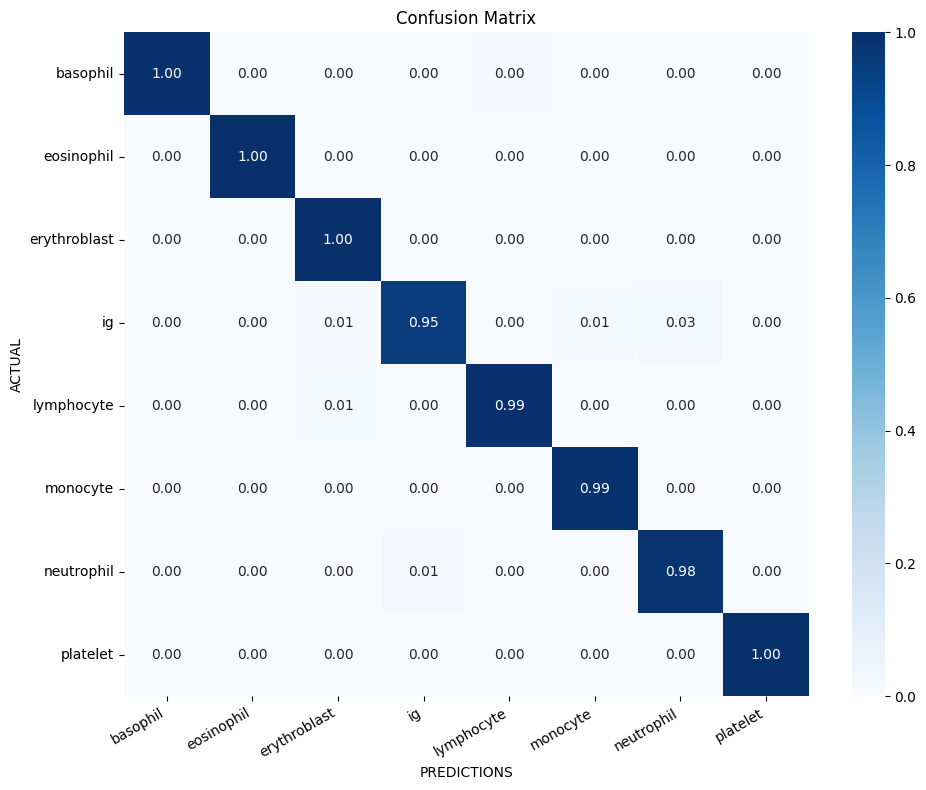

In [11]:
checkpoint = torch.load(SAVE_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        out = model(imgs.to(DEVICE))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(lbls.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print(f'Model Accuracy : {(all_preds==all_labels).mean()*100:.2f}%')
print(classification_report(all_labels, all_preds, target_names=CATEGORIES))

# Confusion matrix
os.makedirs('figures', exist_ok=True)
cf = confusion_matrix(all_labels, all_preds, normalize='true')
plt.figure(figsize=(10, 8))
sns.heatmap(cf, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.xlabel('PREDICTIONS')
plt.ylabel('ACTUAL')
plt.title('Confusion Matrix')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('figures/confusion_matrix.png', dpi=130, bbox_inches='tight')
plt.show()

# Training Curves

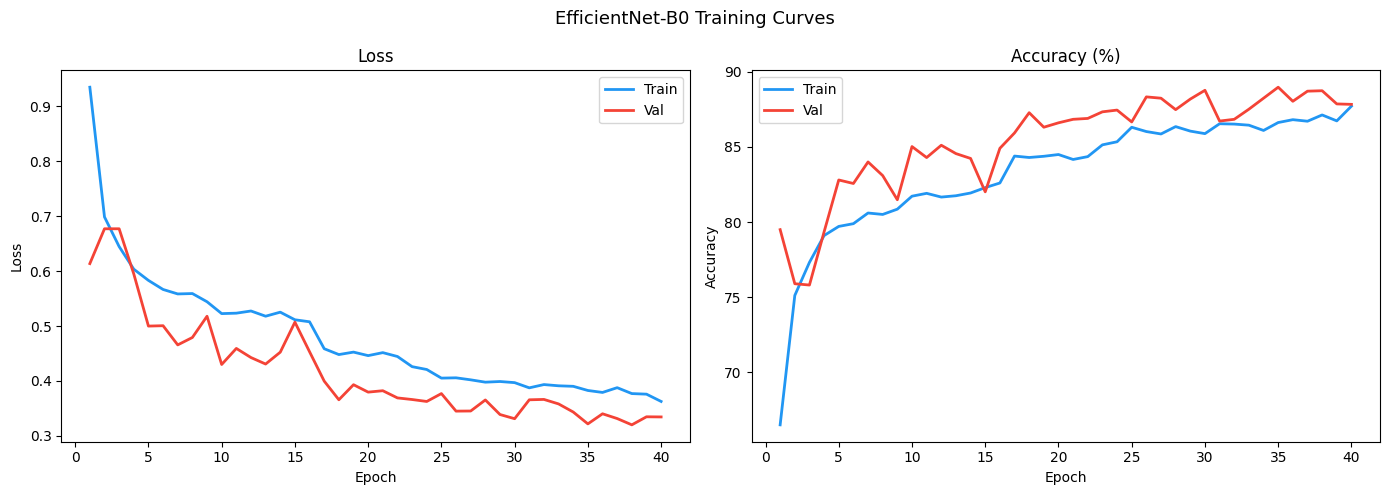

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
e = range(1, len(history['train_loss'])+1)

ax1.plot(e, history['train_loss'], label='Train', color='#2196F3', lw=2)
ax1.plot(e, history['val_loss'],   label='Val',   color='#F44336', lw=2)
ax1.set(title='Loss', xlabel='Epoch', ylabel='Loss')
ax1.legend()

ax2.plot(e, history['train_acc'], label='Train', color='#2196F3', lw=2)
ax2.plot(e, history['val_acc'],   label='Val',   color='#F44336', lw=2)
ax2.set(title='Accuracy (%)', xlabel='Epoch', ylabel='Accuracy')
ax2.legend()

plt.suptitle('EfficientNet-B0 Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig('figures/training_curves.png', dpi=130, bbox_inches='tight')
plt.show()

# Inference Visulaization

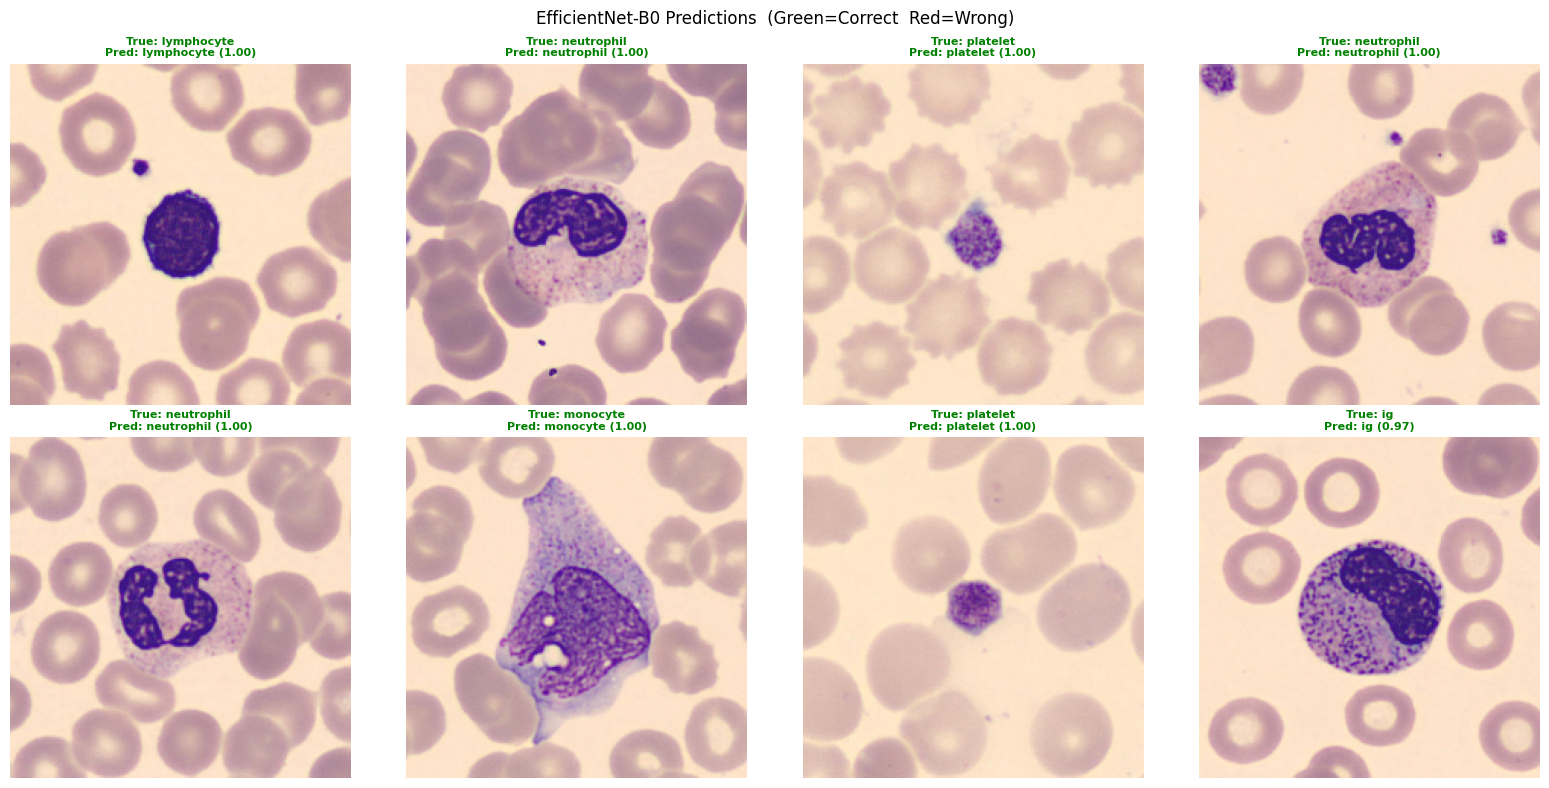

In [13]:
import random
random.seed(42)

indices = random.sample(range(len(X_test)), 8)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

model.eval()
for ax, idx in zip(axes.flatten(), indices):
    img_np     = X_test[idx]
    true_label = y_test[idx]
    tensor     = val_transforms(img_np).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0]
        pred  = probs.argmax().item()
        conf  = probs[pred].item()

    color = 'green' if pred == true_label else 'red'
    ax.imshow(img_np)
    ax.set_title(
        f'True: {CATEGORIES[true_label]}\nPred: {CATEGORIES[pred]} ({conf:.2f})',
        fontsize=8, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('EfficientNet-B0 Predictions  (Green=Correct  Red=Wrong)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/predictions.png', dpi=130, bbox_inches='tight')
plt.show()

In [30]:
!ls /content

BSc_Thesis  drive  sample_data
